# Kindle Hybrid Recommender: unified inference, fusion and evaluation

This notebook combines the final **content-based**, **collaborative filtering** and
**GRU4Rec sequential** models into one reproducible hybrid-recommendation workflow.

It does not retrain the large component models. Instead, it loads their saved assets,
generates candidate-level scores under one shared protocol, then evaluates individual
and hybrid models fairly.

## Implemented hybrid strategies

1. **Adaptive weighted fusion**: combines normalised content, CF and sequential scores;
   weights are selected on validation data and can vary by history length.
2. **Cascade retrieval + sequential re-ranking**: content and CF retrieve a candidate
   pool, then GRU4Rec re-ranks that pool.
3. **Optional switching hybrid**: a lifecycle-style fallback policy for sparse users.

## Important scope

The final content model artifact was not copied into this repository, but its complete
candidate-level validation and test scores were saved in
`Content_Based/content_based_candidate_scores.csv.gz`. Therefore this notebook can run
the fully reproducible **offline hybrid experiment** immediately. Dynamic full-catalogue
content scoring requires the missing content vectorizer/embedding artifact; this is
reported explicitly in the final audit cell.

## 1. Environment and paths

The notebook automatically uses GPU in Colab when available, but all inference code is
also valid on CPU. GPU is recommended because generating GRU4Rec scores for about 13
million user-candidate pairs can take several minutes on CPU.

Run this notebook from the project root after copying the whole project to Colab. Edit
only the path candidates below if your Drive layout differs.

In [42]:
from __future__ import annotations

import gzip
import json
import math
import random
import time
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F

try:
    import seaborn as sns
    sns.set_theme(style="whitegrid", context="notebook")
except ImportError:
    sns = None

SEED = 2026
TOP_K = 10
SCORE_BATCH_USERS = 512
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

PROJECT_ROOT = Path.cwd()
DATA_DIR_CANDIDATES = [
    PROJECT_ROOT / "dataset" / "processed_kindle",
    PROJECT_ROOT / "processed_kindle",
]
DATA_DIR = next((p for p in DATA_DIR_CANDIDATES if p.is_dir()), None)
CONTENT_SCORE_PATH = PROJECT_ROOT / "Content_Based" / "content_based_candidate_scores.csv.gz"
CF_CHECKPOINT = PROJECT_ROOT / "models" / "collaborative_model.pt"
GRU_CHECKPOINT = PROJECT_ROOT / "models" / "gru4rec_best.pt"
OUTPUT_DIR = PROJECT_ROOT / "hybrid_results"
OUTPUT_DIR.mkdir(exist_ok=True)

assert DATA_DIR is not None, f"Cannot find processed_kindle under {PROJECT_ROOT.resolve()}"
assert CONTENT_SCORE_PATH.exists(), f"Missing {CONTENT_SCORE_PATH}"
assert CF_CHECKPOINT.exists(), f"Missing {CF_CHECKPOINT}"
assert GRU_CHECKPOINT.exists(), f"Missing {GRU_CHECKPOINT}"

print("project root:", PROJECT_ROOT.resolve())
print("data directory:", DATA_DIR.resolve())
print("device:", DEVICE)

project root: /Users/weisi/Desktop/unsw/9727/project
data directory: /Users/weisi/Desktop/unsw/9727/project/dataset/processed_kindle
device: cpu


## 2. Load shared data and audit the evaluation protocol

Every model is evaluated on exactly the same candidate set: one held-out positive book
and 100 pre-generated negatives per user. Validation uses only training history; test
uses training history plus the validation interaction. This is the common protocol used
by the content and sequential notebooks.

In [43]:
def parse_item_sequence(value: str) -> list[int]:
    if pd.isna(value) or not str(value).strip():
        return []
    return [int(x) for x in str(value).split()]

train_sequences_df = pd.read_csv(DATA_DIR / "train_sequences.csv")
val_df = pd.read_csv(DATA_DIR / "val.csv")
test_df = pd.read_csv(DATA_DIR / "test.csv")
item_metadata = pd.read_csv(DATA_DIR / "item_metadata.csv")
interactions = pd.read_csv(DATA_DIR / "interactions_clean.csv")

train_sequences = dict(zip(
    train_sequences_df.user_idx.astype(int),
    train_sequences_df.item_seq.map(parse_item_sequence),
))
val_targets = dict(zip(val_df.user_idx.astype(int), val_df.pos_idx.astype(int)))
test_targets = dict(zip(test_df.user_idx.astype(int), test_df.pos_idx.astype(int)))

with open(DATA_DIR / "preprocess_stats.json", encoding="utf-8") as f:
    preprocess_stats = json.load(f)

USER_COUNT = len(train_sequences)
ITEM_COUNT = int(item_metadata.item_idx.max()) + 1
assert set(train_sequences) == set(val_targets) == set(test_targets)
assert USER_COUNT == preprocess_stats["num_users"]
assert ITEM_COUNT == preprocess_stats["num_items"]

train_popularity = np.bincount(
    interactions.loc[interactions["split"] == "train", "item_idx"].to_numpy(),
    minlength=ITEM_COUNT,
).astype(np.float32)
popularity_scores = np.log1p(train_popularity)

test_contexts = {
    user: train_sequences[user] + [val_targets[user]]
    for user in train_sequences
}

print(f"users={USER_COUNT:,}; items={ITEM_COUNT:,}")
print(f"train interactions={preprocess_stats['num_train_interactions']:,}")
print("protocol: validation=train history; test=train history + validation target")

users=64,867; items=81,322
train interactions=884,136
protocol: validation=train history; test=train history + validation target


## 3. Load the canonical content-model candidate scores

The content notebook selected **Weighted-TFIDF-TUNED** using validation NDCG@10 and
exported a score for every official candidate. This file is used as the canonical
candidate ordering for all models, so it prevents the previous collaborative-filtering
candidate-set mismatch (where a negative was accidentally treated as a positive).

In [44]:
def load_canonical_split(split: str) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """Return users, candidates, content scores and positive-at-column-zero labels."""
    frame = pd.read_csv(
        CONTENT_SCORE_PATH,
        compression="gzip",
        usecols=["user_idx", "item_idx", "split", "score", "is_positive"],
    )
    frame = frame.loc[frame["split"] == split].copy()
    frame.sort_values(["user_idx"], kind="stable", inplace=True)
    group_sizes = frame.groupby("user_idx", sort=True).size()
    assert len(group_sizes) == USER_COUNT and group_sizes.eq(101).all(), "Expected 101 candidates/user"

    users = group_sizes.index.to_numpy(dtype=np.int64)
    candidates = frame.item_idx.to_numpy(dtype=np.int64).reshape(-1, 101)
    scores = frame.score.to_numpy(dtype=np.float32).reshape(-1, 101)
    positives = frame.is_positive.astype(bool).to_numpy().reshape(-1, 101)
    assert positives[:, 0].all() and positives.sum() == len(users), "Positive must be first candidate"
    return users, candidates, scores, positives

val_users, val_candidates, val_content_scores, val_positive_mask = load_canonical_split("validation")
test_users, test_candidates, test_content_scores, test_positive_mask = load_canonical_split("test")

assert np.array_equal(val_users, test_users)
assert np.array_equal(val_candidates[:, 0], np.array([val_targets[u] for u in val_users]))
assert np.array_equal(test_candidates[:, 0], np.array([test_targets[u] for u in test_users]))

print("canonical score file verified")
print("validation matrix:", val_candidates.shape, "test matrix:", test_candidates.shape)

canonical score file verified
validation matrix: (64867, 101) test matrix: (64867, 101)


## 4. Recreate the two saved PyTorch inference models

The collaborative checkpoint stores only embedding weights, so the small Two-Tower
architecture is reconstructed here. The sequential checkpoint stores its GRU4Rec
configuration and state dictionary. No training is performed in this notebook.

In [45]:
class TwoTowerInference(nn.Module):
    """Matches the final CF notebook when use_mlp_layers=False."""
    def __init__(self, n_users: int, n_items: int, embedding_dim: int):
        super().__init__()
        self.user_embedding = nn.Embedding(n_users, embedding_dim)
        self.item_embedding = nn.Embedding(n_items, embedding_dim)

    def score_candidates(self, users: torch.Tensor, candidates: torch.Tensor) -> torch.Tensor:
        user_vec = F.normalize(self.user_embedding(users), p=2, dim=1)
        item_vec = F.normalize(self.item_embedding(candidates), p=2, dim=2)
        return torch.einsum("bd,bcd->bc", user_vec, item_vec)


class GRU4RecInference(nn.Module):
    """Architecture matched to SASRec_Sequential_Recommender.ipynb."""
    def __init__(self, num_items: int, max_len: int, hidden_dim: int, num_layers: int, dropout: float):
        super().__init__()
        self.max_len = max_len
        self.item_embedding = nn.Embedding(num_items + 1, hidden_dim, padding_idx=0)
        self.gru = nn.GRU(
            hidden_dim, hidden_dim, num_layers=num_layers, batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )
        self.dropout = nn.Dropout(dropout)

    def forward(self, item_ids: torch.Tensor) -> torch.Tensor:
        lengths = item_ids.ne(0).sum(dim=1).clamp_min(1).cpu()
        embedded = self.dropout(self.item_embedding(item_ids))
        packed = nn.utils.rnn.pack_padded_sequence(
            embedded, lengths, batch_first=True, enforce_sorted=False
        )
        packed_outputs, _ = self.gru(packed)
        output, _ = nn.utils.rnn.pad_packed_sequence(
            packed_outputs, batch_first=True, total_length=self.max_len
        )
        return self.dropout(output)

    def score_candidates(self, item_ids: torch.Tensor, candidate_ids: torch.Tensor) -> torch.Tensor:
        features = self(item_ids)
        final_pos = item_ids.ne(0).sum(dim=1).clamp_min(1).sub(1)
        context = features[torch.arange(item_ids.size(0), device=item_ids.device), final_pos]
        return torch.einsum("bd,bcd->bc", context, self.item_embedding(candidate_ids))


def safe_torch_load(path: Path):
    try:
        return torch.load(path, map_location="cpu", weights_only=False)
    except TypeError:  # compatibility with older PyTorch versions
        return torch.load(path, map_location="cpu")


cf_state = safe_torch_load(CF_CHECKPOINT)
cf_user_shape = cf_state["usermodel.model.weight"].shape
cf_item_shape = cf_state["itemmodel.model.weight"].shape
assert cf_user_shape[0] == USER_COUNT and cf_item_shape[0] == ITEM_COUNT
assert cf_user_shape[1] == cf_item_shape[1]

cf_model = TwoTowerInference(USER_COUNT, ITEM_COUNT, cf_user_shape[1])
cf_model.user_embedding.weight.data.copy_(cf_state["usermodel.model.weight"])
cf_model.item_embedding.weight.data.copy_(cf_state["itemmodel.model.weight"])
cf_model = cf_model.to(DEVICE).eval()

gru_checkpoint = safe_torch_load(GRU_CHECKPOINT)
gru_config = gru_checkpoint["config"]
assert gru_checkpoint["num_items"] == ITEM_COUNT
assert gru_checkpoint.get("raw_to_model_item_offset", 1) == 1
gru_model = GRU4RecInference(
    num_items=ITEM_COUNT,
    max_len=int(gru_config["max_len"]),
    hidden_dim=int(gru_config["hidden_dim"]),
    num_layers=int(gru_config["num_layers"]),
    dropout=float(gru_config["dropout"]),
)
gru_model.load_state_dict(gru_checkpoint["model_state_dict"])
gru_model = gru_model.to(DEVICE).eval()

print("CF embedding dimension:", cf_user_shape[1])
print("GRU4Rec config:", {k: gru_config[k] for k in ["name", "max_len", "hidden_dim", "num_layers", "dropout"]})

CF embedding dimension: 128
GRU4Rec config: {'name': 'GRU4Rec-short-20', 'max_len': 20, 'hidden_dim': 64, 'num_layers': 1, 'dropout': 0.1}


## 5. Generate or reuse aligned CF and GRU4Rec candidate scores

Both saved models score the **same 101 candidates in the same order** as the content
file. Cached `.npy` arrays make repeated fusion experiments fast. Delete the cache files
in `hybrid_results/` only if a component checkpoint changes.

In [46]:
def right_pad_context(history: list[int], max_len: int) -> np.ndarray:
    history = list(history)[-max_len:]
    padded = np.zeros(max_len, dtype=np.int64)
    if history:
        padded[:len(history)] = np.asarray(history, dtype=np.int64) + 1
    return padded


@torch.no_grad()
def score_cf(users: np.ndarray, candidates: np.ndarray) -> np.ndarray:
    blocks = []
    for start in range(0, len(users), SCORE_BATCH_USERS):
        end = start + SCORE_BATCH_USERS
        u = torch.as_tensor(users[start:end], dtype=torch.long, device=DEVICE)
        c = torch.as_tensor(candidates[start:end], dtype=torch.long, device=DEVICE)
        blocks.append(cf_model.score_candidates(u, c).cpu().numpy().astype(np.float32))
    return np.vstack(blocks)


@torch.no_grad()
def score_gru(users: np.ndarray, candidates: np.ndarray, contexts: dict[int, list[int]]) -> np.ndarray:
    blocks = []
    max_len = int(gru_config["max_len"])
    for start in range(0, len(users), SCORE_BATCH_USERS):
        end = start + SCORE_BATCH_USERS
        histories = np.stack([right_pad_context(contexts[int(u)], max_len) for u in users[start:end]])
        # Model IDs reserve zero for padding, hence raw item index + 1.
        c = candidates[start:end] + 1
        history_tensor = torch.as_tensor(histories, dtype=torch.long, device=DEVICE)
        candidate_tensor = torch.as_tensor(c, dtype=torch.long, device=DEVICE)
        blocks.append(gru_model.score_candidates(history_tensor, candidate_tensor).cpu().numpy().astype(np.float32))
    return np.vstack(blocks)


def load_or_generate_scores(name: str, split: str, scorer, users, candidates, contexts=None) -> np.ndarray:
    path = OUTPUT_DIR / f"{name}_{split}_candidate_scores.npy"
    if path.exists():
        scores = np.load(path)
        assert scores.shape == candidates.shape
        print(f"loaded cached {path.name}")
        return scores
    started = time.time()
    scores = scorer(users, candidates) if contexts is None else scorer(users, candidates, contexts)
    np.save(path, scores)
    print(f"generated {path.name} in {time.time() - started:.1f}s")
    return scores


val_cf_scores = load_or_generate_scores("cf", "validation", score_cf, val_users, val_candidates)
test_cf_scores = load_or_generate_scores("cf", "test", score_cf, test_users, test_candidates)
val_gru_scores = load_or_generate_scores("gru4rec", "validation", score_gru, val_users, val_candidates, train_sequences)
test_gru_scores = load_or_generate_scores("gru4rec", "test", score_gru, test_users, test_candidates, test_contexts)

loaded cached cf_validation_candidate_scores.npy
loaded cached cf_test_candidate_scores.npy
loaded cached gru4rec_validation_candidate_scores.npy
loaded cached gru4rec_test_candidate_scores.npy


## 6. Shared ranking metrics and catalogue diagnostics

The positive book is stored in candidate column zero. Scores are converted to a rank for
each user, then aggregated into Recall/Hit@10, Precision@10, NDCG@10 and MRR. Catalogue
metrics are computed from each model's Top-10 test recommendations.

In [47]:
def ranks_from_scores(scores: np.ndarray) -> np.ndarray:
    """Positive is column zero; stable sorting resolves exact ties reproducibly."""
    order = np.argsort(-scores, axis=1, kind="stable")
    return np.argmax(order == 0, axis=1) + 1


def ranking_metrics(scores: np.ndarray, k: int = TOP_K) -> dict[str, float]:
    ranks = ranks_from_scores(scores)
    hits = ranks <= k
    return {
        f"Hit@{k}": float(hits.mean()),
        f"Recall@{k}": float(hits.mean()),
        f"Precision@{k}": float(hits.mean() / k),
        f"NDCG@{k}": float(np.where(hits, 1.0 / np.log2(ranks + 1), 0.0).mean()),
        "MRR": float((1.0 / ranks).mean()),
        "users": int(len(ranks)),
    }


item_categories = {
    int(row.item_idx): frozenset(x.strip() for x in str(row.categories).split(";") if x.strip())
    for row in item_metadata.itertuples()
}


def catalogue_metrics(scores: np.ndarray, candidates: np.ndarray, k: int = TOP_K) -> dict[str, float]:
    top_positions = np.argsort(-scores, axis=1, kind="stable")[:, :k]
    top_items = np.take_along_axis(candidates, top_positions, axis=1)
    flat_items = top_items.ravel()
    total = float(train_popularity.sum() + ITEM_COUNT)
    novelty = float(np.mean(-np.log2((train_popularity[flat_items] + 1.0) / total)))
    diversities = []
    for row in top_items:
        pair_sims = []
        for i in range(len(row)):
            for j in range(i + 1, len(row)):
                left, right = item_categories.get(int(row[i]), frozenset()), item_categories.get(int(row[j]), frozenset())
                pair_sims.append(len(left & right) / max(len(left | right), 1))
        diversities.append(1.0 - np.mean(pair_sims) if pair_sims else 0.0)
    return {
        "CatalogueCoverage": float(len(np.unique(flat_items)) / ITEM_COUNT),
        "Novelty": novelty,
        "IntraListDiversity": float(np.mean(diversities)),
    }


def evaluate_model(name: str, validation_scores: np.ndarray, test_scores: np.ndarray) -> list[dict]:
    rows = []
    for split, scores, candidates in [
        ("validation", validation_scores, val_candidates),
        ("test", test_scores, test_candidates),
    ]:
        rows.append({"model": name, "split": split, **ranking_metrics(scores), **catalogue_metrics(scores, candidates)})
    return rows

## 7. Evaluate the individual models

Before fusion, re-evaluate content, CF and GRU4Rec under one implementation and one
candidate protocol. A popularity baseline is also included to make gains interpretable.

In [48]:
val_popularity_scores = popularity_scores[val_candidates]
test_popularity_scores = popularity_scores[test_candidates]

results = []
results += evaluate_model("Popularity", val_popularity_scores, test_popularity_scores)
results += evaluate_model("Content: Weighted-TFIDF", val_content_scores, test_content_scores)
results += evaluate_model("Collaborative Filtering: Two-Tower", val_cf_scores, test_cf_scores)
results += evaluate_model("Sequential: GRU4Rec", val_gru_scores, test_gru_scores)

single_model_results = pd.DataFrame(results)
display(single_model_results.sort_values(["split", f"NDCG@{TOP_K}"], ascending=[True, False]))

,model,split,Hit@10,Recall@10,Precision@10,NDCG@10,MRR,users,CatalogueCoverage,Novelty,IntraListDiversity
5,Collaborative Filtering: Two-Tower,test,0.748902,0.748902,0.074890,0.534441,0.478403,64867,0.985969,16.478277,0.673156
3,Content: Weighted-TFIDF,test,0.591441,0.591441,0.059144,0.428251,0.393531,64867,0.818315,16.460440,0.547997
7,Sequential: GRU4Rec,test,0.640726,0.640726,0.064073,0.423703,0.371448,64867,0.832739,15.828933,0.679505
1,Popularity,test,0.381195,0.381195,0.038120,0.235453,0.209538,64867,0.181611,14.679614,0.676371
4,Collaborative Filtering: Two-Tower,validation,0.803644,0.803644,0.080364,0.598337,0.542811,64867,0.986301,16.462017,0.671941
6,Sequential: GRU4Rec,validation,0.677741,0.677741,0.067774,0.455494,0.400256,64867,0.833895,15.793038,0.682704
2,Content: Weighted-TFIDF,validation,0.593152,0.593152,0.059315,0.434093,0.400600,64867,0.833587,16.458807,0.552901
0,Popularity,validation,0.412567,0.412567,0.041257,0.256567,0.227543,64867,0.181845,14.674565,0.676716


## 8. Hybrid 1: adaptive weighted score fusion

Raw scores have different numeric scales, so each user's 101 candidate scores are
z-normalised before fusion. We search non-negative weights that sum to one on validation
NDCG@10, then apply the selected weights exactly once to test data.

In [49]:
def z_normalise(scores: np.ndarray) -> np.ndarray:
    mean = scores.mean(axis=1, keepdims=True)
    std = scores.std(axis=1, keepdims=True)
    return (scores - mean) / np.maximum(std, 1e-8)


def weighted_fusion(content: np.ndarray, cf: np.ndarray, gru: np.ndarray, weights: tuple[float, float, float]) -> np.ndarray:
    wc, wf, ws = weights
    return wc * z_normalise(content) + wf * z_normalise(cf) + ws * z_normalise(gru)


coarse_results = []
coarse_grid = np.arange(0.0, 1.01, 0.1)
for wc in coarse_grid:
    for wf in coarse_grid:
        ws = round(1.0 - wc - wf, 10)
        if ws < 0:
            continue
        weights = (float(wc), float(wf), float(ws))
        metrics = ranking_metrics(weighted_fusion(val_content_scores, val_cf_scores, val_gru_scores, weights))

        coarse_results.append({"content_weight": wc, "cf_weight": wf, "gru_weight": ws, **metrics})

coarse_search = (pd.DataFrame(coarse_results).sort_values(f"NDCG@{TOP_K}", ascending=False).reset_index(drop=True))
coarse_best = tuple(coarse_search.loc[0,["content_weight", "cf_weight", "gru_weight"]].astype(float))
print("Coarse best weights:", coarse_best)
display(coarse_search.head())


best_wc, best_wf, _ = coarse_best
fine_results = []
wc_range = np.arange( max(0, best_wc - 0.1), min(1, best_wc + 0.1) + 0.001,0.01,)
wf_range = np.arange(max(0, best_wf - 0.1),min(1, best_wf + 0.1) + 0.001,0.01,)

for wc in wc_range:
    for wf in wf_range:
        ws = round(1.0 - wc - wf, 10)
        if ws < 0 or ws > 1:
            continue

        weights = (round(float(wc), 2), round(float(wf), 2), round(float(ws), 2),)
        metrics = ranking_metrics( weighted_fusion( val_content_scores, val_cf_scores, val_gru_scores, weights))
        fine_results.append({"content_weight": weights[0], "cf_weight": weights[1], "gru_weight": weights[2],**metrics})

fine_search = (pd.DataFrame(fine_results).sort_values(f"NDCG@{TOP_K}", ascending=False).reset_index(drop=True))
best_weights = tuple(fine_search.loc[0,["content_weight", "cf_weight", "gru_weight"]].astype(float))

print("Final best weights:", best_weights)
display(fine_search.head(10))

Coarse best weights: (0.2, 0.4, 0.4)


,content_weight,cf_weight,gru_weight,Hit@10,Recall@10,Precision@10,NDCG@10,MRR,users
0,0.2,0.4,0.4,0.847503,0.847503,0.084750,0.658924,0.606816,64867
1,0.2,0.5,0.3,0.848305,0.848305,0.084830,0.656599,0.603521,64867
2,0.3,0.4,0.3,0.844297,0.844297,0.084430,0.653322,0.600716,64867
3,0.2,0.3,0.5,0.837992,0.837992,0.083799,0.653216,0.602604,64867
4,0.1,0.5,0.4,0.844975,0.844975,0.084498,0.653214,0.600223,64867


Final best weights: (0.19, 0.42, 0.39)


,content_weight,cf_weight,gru_weight,Hit@10,Recall@10,Precision@10,NDCG@10,MRR,users
0,0.19,0.42,0.39,0.847920,0.847920,0.084792,0.659047,0.606835,64867
1,0.18,0.44,0.38,0.848367,0.848367,0.084837,0.659022,0.606636,64867
2,0.20,0.41,0.39,0.847658,0.847658,0.084766,0.659000,0.606874,64867
3,0.20,0.42,0.38,0.848274,0.848274,0.084827,0.658969,0.606616,64867
4,0.19,0.43,0.38,0.848228,0.848228,0.084823,0.658962,0.606617,64867
5,0.18,0.45,0.37,0.848875,0.848875,0.084888,0.658934,0.606352,64867
6,0.20,0.39,0.41,0.847149,0.847149,0.084715,0.658931,0.606948,64867
7,0.20,0.40,0.40,0.847503,0.847503,0.084750,0.658924,0.606816,64867
8,0.20,0.43,0.37,0.848598,0.848598,0.084860,0.658915,0.606432,64867
9,0.21,0.41,0.38,0.847966,0.847966,0.084797,0.658912,0.606659,64867


## 9. Hybrid 2: cascade retrieval and sequential re-ranking

For the offline protocol, each model starts with the same 101 official candidates. Content
and CF each retrieve their Top-N candidates; their union is then re-ranked by a weighted
combination of GRU4Rec, content and CF. Candidates outside the retrieval union are placed
below the pool. In a production full-catalogue system, this corresponds to inexpensive
content/CF retrieval followed by a more focused sequential re-ranker.

In [50]:
def cascade_fusion(content: np.ndarray, cf: np.ndarray, gru: np.ndarray, retrieve_k: int, rerank_weights: tuple[float, float, float]) -> np.ndarray:
    n_users, n_candidates = content.shape
    content_top = np.argpartition(-content, kth=retrieve_k - 1, axis=1)[:, :retrieve_k]
    cf_top = np.argpartition(-cf, kth=retrieve_k - 1, axis=1)[:, :retrieve_k]
    pool = np.zeros((n_users, n_candidates), dtype=bool)
    rows = np.arange(n_users)[:, None]
    pool[rows, content_top] = True
    pool[rows, cf_top] = True
    rerank = weighted_fusion(content, cf, gru, rerank_weights)
    return np.where(pool, rerank, -np.inf)


cascade_trials = []
for retrieve_k in [20, 30, 40, 50]:
    for gru_weight in [0.50, 0.65, 0.80]:
        remaining = 1.0 - gru_weight
        # Keep a content bias in retrieval/re-ranking to preserve long-term preferences.
        rerank_weights = (remaining * 0.6, remaining * 0.4, gru_weight)
        scores = cascade_fusion(val_content_scores, val_cf_scores, val_gru_scores, retrieve_k, rerank_weights)
        cascade_trials.append({"retrieve_k_per_model": retrieve_k, "content_weight": rerank_weights[0], "cf_weight": rerank_weights[1], "gru_weight": rerank_weights[2], **ranking_metrics(scores)})

cascade_search = pd.DataFrame(cascade_trials).sort_values(f"NDCG@{TOP_K}", ascending=False).reset_index(drop=True)
best_cascade = cascade_search.iloc[0]
best_cascade_weights = (float(best_cascade.content_weight), float(best_cascade.cf_weight), float(best_cascade.gru_weight))
best_retrieve_k = int(best_cascade.retrieve_k_per_model)
display(cascade_search.head(10))
print("selected cascade configuration:", best_retrieve_k, best_cascade_weights)

val_cascade_scores = cascade_fusion(val_content_scores, val_cf_scores, val_gru_scores, best_retrieve_k, best_cascade_weights)
test_cascade_scores = cascade_fusion(test_content_scores, test_cf_scores, test_gru_scores, best_retrieve_k, best_cascade_weights)
results += evaluate_model("Hybrid 2: Cascade", val_cascade_scores, test_cascade_scores)

,retrieve_k_per_model,content_weight,cf_weight,gru_weight,Hit@10,Recall@10,Precision@10,NDCG@10,MRR,users
0,30,0.30,0.20,0.50,0.825874,0.825874,0.082587,0.639938,0.589608,64867
1,50,0.30,0.20,0.50,0.825828,0.825828,0.082583,0.639874,0.589489,64867
2,40,0.30,0.20,0.50,0.825767,0.825767,0.082577,0.639852,0.589498,64867
3,20,0.30,0.20,0.50,0.825042,0.825042,0.082504,0.639492,0.589538,64867
4,20,0.21,0.14,0.65,0.814189,0.814189,0.081419,0.625796,0.575725,64867
5,30,0.21,0.14,0.65,0.810597,0.810597,0.081060,0.624032,0.574426,64867
6,40,0.21,0.14,0.65,0.808670,0.808670,0.080867,0.622913,0.573535,64867
7,50,0.21,0.14,0.65,0.807175,0.807175,0.080717,0.622277,0.573137,64867
8,20,0.12,0.08,0.80,0.792946,0.792946,0.079295,0.590846,0.537957,64867
9,30,0.12,0.08,0.80,0.781168,0.781168,0.078117,0.584037,0.532878,64867


selected cascade configuration: 30 (0.3, 0.2, 0.5)


## 10. Optional Hybrid 3: lifecycle switching policy

This policy mirrors the project design: content dominates sparse-user recommendations,
while CF and GRU4Rec take over as user history grows. It is not tuned on the test set;
the simple thresholds below are explicit design choices and can be tuned only on validation.

In [51]:
def switching_fusion(content: np.ndarray, cf: np.ndarray, gru: np.ndarray, histories: dict[int, list[int]], users: np.ndarray) -> np.ndarray:
    output = np.empty_like(content, dtype=np.float32)
    c, f, s = z_normalise(content), z_normalise(cf), z_normalise(gru)
    for row, user in enumerate(users):
        n_history = len(histories[int(user)])
        if n_history < 5:
            weights = (0.80, 0.20, 0.00)
        elif n_history < 20:
            weights = (0.45, 0.35, 0.20)
        else:
            weights = (0.20, 0.35, 0.45)
        output[row] = weights[0] * c[row] + weights[1] * f[row] + weights[2] * s[row]
    return output


val_switching_scores = switching_fusion(val_content_scores, val_cf_scores, val_gru_scores, train_sequences, val_users)
test_switching_scores = switching_fusion(test_content_scores, test_cf_scores, test_gru_scores, test_contexts, test_users)
results += evaluate_model("Hybrid 3: Switching", val_switching_scores, test_switching_scores)

## 11. Compare Hybrid methods and optimise Adaptive Weighted

First compare the three original Hybrid methods using the shared protocol. Since Adaptive Weighted is the validation winner, the following experiments optimise it through three independent routes:

- 1. alternative score normalisation;
- 2. a lightweight Learning-to-Rank meta-ranker;
- 3. nonlinear Random Fourier Feature (RFF) ranking.

To avoid using the test set for model selection, validation users are deterministically divided into meta-training users and held-out selection users. The final winning approach is refit with all validation users only after selection.


In [53]:
# --- 11.1 Compare the original three Hybrid approaches ---
original_hybrid_names = [
    "Hybrid 1: Adaptive Weighted",
    "Hybrid 2: Cascade",
    "Hybrid 3: Switching",
]
original_hybrid_results = (
    pd.DataFrame(results)
    .loc[lambda frame: frame["model"].isin(original_hybrid_names)]
    .drop_duplicates(subset=["model", "split"], keep="last")
    .copy()
)
missing_hybrids = set(original_hybrid_names) - set(original_hybrid_results["model"])
if missing_hybrids:
    raise RuntimeError("Run Sections 8-10 first. Missing: " + ", ".join(sorted(missing_hybrids)))

display(original_hybrid_results.sort_values(["split", f"NDCG@{TOP_K}"], ascending=[True, False]))

hybrid_validation = original_hybrid_results.query("split == 'validation'").sort_values(
    f"NDCG@{TOP_K}", ascending=False
)
if hybrid_validation.iloc[0]["model"] != "Hybrid 1: Adaptive Weighted":
    raise RuntimeError(
        "Adaptive Weighted is not the validation-winning Hybrid, so it should not be "
        "the target of the following optimisation section."
    )
print("Validation-winning Hybrid:", hybrid_validation.iloc[0]["model"])


,model,split,Hit@10,Recall@10,Precision@10,NDCG@10,MRR,users,CatalogueCoverage,Novelty,IntraListDiversity
13,Hybrid 1: Adaptive Weighted,test,0.817195,0.817195,0.081720,0.615942,0.561382,64867,0.916702,16.140322,0.633246
9,Hybrid 2: Cascade,test,0.801794,0.801794,0.080179,0.608813,0.557373,64867,0.871105,16.034292,0.615482
11,Hybrid 3: Switching,test,0.773583,0.773583,0.077358,0.576465,0.525090,64867,0.914623,16.283644,0.588850
12,Hybrid 1: Adaptive Weighted,validation,0.847920,0.847920,0.084792,0.659047,0.606835,64867,0.917046,16.117622,0.636232
8,Hybrid 2: Cascade,validation,0.825874,0.825874,0.082587,0.639938,0.589608,64867,0.874585,16.009109,0.620189
10,Hybrid 3: Switching,validation,0.774076,0.774076,0.077408,0.585709,0.536854,64867,0.920575,16.301683,0.588725


Validation-winning Hybrid: Hybrid 1: Adaptive Weighted


In [54]:
# --- 11.2 Shared helpers and validation split for Adaptive Weighted optimisation ---
from sklearn.kernel_approximation import RBFSampler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

OPTIMISATION_SEED = SEED + 91
LTR_MAX_TRAIN_USERS = 15_000
LTR_NEGATIVES_PER_USER = 20
RFF_COMPONENTS = 96

# Use user identity only to create a reproducible, disjoint validation meta-train/select split.
meta_train_mask = (val_users % 5) != 0
selection_mask = ~meta_train_mask
assert meta_train_mask.any() and selection_mask.any()

def normalise_scores(scores: np.ndarray, method: str) -> np.ndarray:
    if method == "zscore":
        return z_normalise(scores)
    if method == "minmax":
        low = scores.min(axis=1, keepdims=True)
        high = scores.max(axis=1, keepdims=True)
        return (scores - low) / np.maximum(high - low, 1e-8)
    if method == "rank":
        # Highest-scoring candidate receives 1.0, lowest receives 0.0.
        order = np.argsort(-scores, axis=1, kind="stable")
        ranks = np.empty_like(order)
        rows = np.arange(scores.shape[0])[:, None]
        ranks[rows, order] = np.arange(scores.shape[1])
        return 1.0 - ranks / max(scores.shape[1] - 1, 1)
    raise ValueError(f"Unknown normalisation method: {method}")

def normalised_fusion(content, cf, gru, weights, method: str) -> np.ndarray:
    wc, wf, ws = weights
    return (
        wc * normalise_scores(content, method)
        + wf * normalise_scores(cf, method)
        + ws * normalise_scores(gru, method)
    )

def weight_candidates(step: float = 0.1):
    grid = np.arange(0.0, 1.0 + step / 2, step)
    for wc in grid:
        for wf in grid:
            ws = round(1.0 - float(wc) - float(wf), 10)
            if ws >= -1e-9:
                yield (float(wc), float(wf), max(0.0, float(ws)))

def select_fusion_weights(content, cf, gru, mask, method: str):
    best_row = None
    for weights in weight_candidates():
        metrics = ranking_metrics(normalised_fusion(content[mask], cf[mask], gru[mask], weights, method))
        row = {"content_weight": weights[0], "cf_weight": weights[1], "gru_weight": weights[2], **metrics}
        if best_row is None or row[f"NDCG@{TOP_K}"] > best_row[f"NDCG@{TOP_K}"]:
            best_row = row
    return best_row

def history_lengths(users, histories):
    return np.asarray([len(histories[int(user)]) for user in users], dtype=np.float32)

def base_features(users, candidates, content, cf, gru, histories):
    """Candidate-level features shared by linear LTR and nonlinear RFF ranking."""
    n_users, n_candidates = candidates.shape
    lengths = np.log1p(history_lengths(users, histories)) / np.log1p(
        max(max(len(value) for value in histories.values()), 1)
    )
    popularity_feature = np.log1p(train_popularity[candidates]) / np.log1p(
        max(float(train_popularity.max()), 1.0)
    )
    return np.column_stack([
        z_normalise(content).reshape(-1),
        z_normalise(cf).reshape(-1),
        z_normalise(gru).reshape(-1),
        np.repeat(lengths, n_candidates),
        popularity_feature.reshape(-1),
    ]).astype(np.float32)

def sampled_ltr_training_data(users, candidates, content, cf, gru, histories, mask, seed):
    rng = np.random.default_rng(seed)
    eligible = np.flatnonzero(mask)
    selected_rows = rng.choice(
        eligible,
        size=min(LTR_MAX_TRAIN_USERS, len(eligible)),
        replace=False,
    )
    neg_positions = np.stack([
        rng.choice(np.arange(1, candidates.shape[1]), size=LTR_NEGATIVES_PER_USER, replace=False)
        for _ in selected_rows
    ])
    positions = np.column_stack([
        np.zeros(len(selected_rows), dtype=np.int64),
        neg_positions,
    ])
    all_features = base_features(
        users[selected_rows], candidates[selected_rows], content[selected_rows],
        cf[selected_rows], gru[selected_rows], histories,
    ).reshape(len(selected_rows), candidates.shape[1], -1)
    x = all_features[np.arange(len(selected_rows))[:, None], positions].reshape(-1, all_features.shape[-1])
    y = (positions.reshape(-1) == 0).astype(np.int8)
    return x, y

def score_meta_ranker(model, users, candidates, content, cf, gru, histories, batch_users=1_024):
    output = np.empty(content.shape, dtype=np.float32)
    for start in range(0, len(users), batch_users):
        end = min(start + batch_users, len(users))
        features = base_features(
            users[start:end], candidates[start:end], content[start:end],
            cf[start:end], gru[start:end], histories,
        )
        output[start:end] = model.predict_proba(features)[:, 1].reshape(end - start, candidates.shape[1])
    return output


In [55]:
# --- 11.3 Optimisation route A: replace z-score normalisation ---
optimisation_rows = []
optimisation_score_sets = {}

# The original Adaptive Weighted model is the baseline with Section 8's fine-search weights.
baseline_val_scores = normalised_fusion(
    val_content_scores, val_cf_scores, val_gru_scores, best_weights, "zscore"
)
baseline_test_scores = normalised_fusion(
    test_content_scores, test_cf_scores, test_gru_scores, best_weights, "zscore"
)
optimisation_score_sets["Original Adaptive Weighted"] = (baseline_val_scores, baseline_test_scores)
optimisation_rows.append({
    "method": "Original Adaptive Weighted (z-score)",
    "route": "baseline",
    "selected_weights": str(tuple(round(value, 3) for value in best_weights)),
    "selection_NDCG@10": ranking_metrics(baseline_val_scores[selection_mask])[f"NDCG@{TOP_K}"],
    "test_NDCG@10": ranking_metrics(baseline_test_scores)[f"NDCG@{TOP_K}"],
    "test_Recall@10": ranking_metrics(baseline_test_scores)[f"Recall@{TOP_K}"],
    "test_MRR": ranking_metrics(baseline_test_scores)["MRR"],
})

for method in ("minmax", "rank"):
    selection_weights = select_fusion_weights(
        val_content_scores, val_cf_scores, val_gru_scores, meta_train_mask, method
    )
    weights = (
        selection_weights["content_weight"],
        selection_weights["cf_weight"],
        selection_weights["gru_weight"],
    )
    validation_scores = normalised_fusion(
        val_content_scores, val_cf_scores, val_gru_scores, weights, method
    )
    selection_ndcg = ranking_metrics(validation_scores[selection_mask])[f"NDCG@{TOP_K}"]

    # Re-select the same normaliser's weights using all validation users before final test.
    full_weights_row = select_fusion_weights(
        val_content_scores, val_cf_scores, val_gru_scores,
        np.ones(len(val_users), dtype=bool), method,
    )
    full_weights = (
        full_weights_row["content_weight"],
        full_weights_row["cf_weight"],
        full_weights_row["gru_weight"],
    )
    test_scores = normalised_fusion(
        test_content_scores, test_cf_scores, test_gru_scores, full_weights, method
    )
    label = f"Adaptive Weighted ({method} normalisation)"
    optimisation_score_sets[label] = (validation_scores, test_scores)
    optimisation_rows.append({
        "method": label,
        "route": "normalisation",
        "selected_weights": str(tuple(round(value, 3) for value in full_weights)),
        "selection_NDCG@10": selection_ndcg,
        "test_NDCG@10": ranking_metrics(test_scores)[f"NDCG@{TOP_K}"],
        "test_Recall@10": ranking_metrics(test_scores)[f"Recall@{TOP_K}"],
        "test_MRR": ranking_metrics(test_scores)["MRR"],
    })


,method,route,selected_weights,selection_NDCG@10,test_NDCG@10,test_Recall@10,test_MRR
0,Adaptive Weighted + linear LTR,Learning to Rank,learned,0.665072,0.617099,0.818644,0.562329
1,Original Adaptive Weighted (z-score),baseline,"(0.19, 0.42, 0.39)",0.660569,0.615942,0.817195,0.561382
2,Adaptive Weighted (minmax normalisation),normalisation,"(0.2, 0.4, 0.4)",0.656428,0.612017,0.814729,0.557094
3,Adaptive Weighted (rank normalisation),normalisation,"(0.1, 0.8, 0.1)",0.618301,0.562885,0.780520,0.504503
4,Adaptive Weighted + RFF ranker,RFF,learned,0.469386,0.439979,0.731373,0.362372


Best Adaptive Weighted variant selected on held-out validation users: Adaptive Weighted + linear LTR


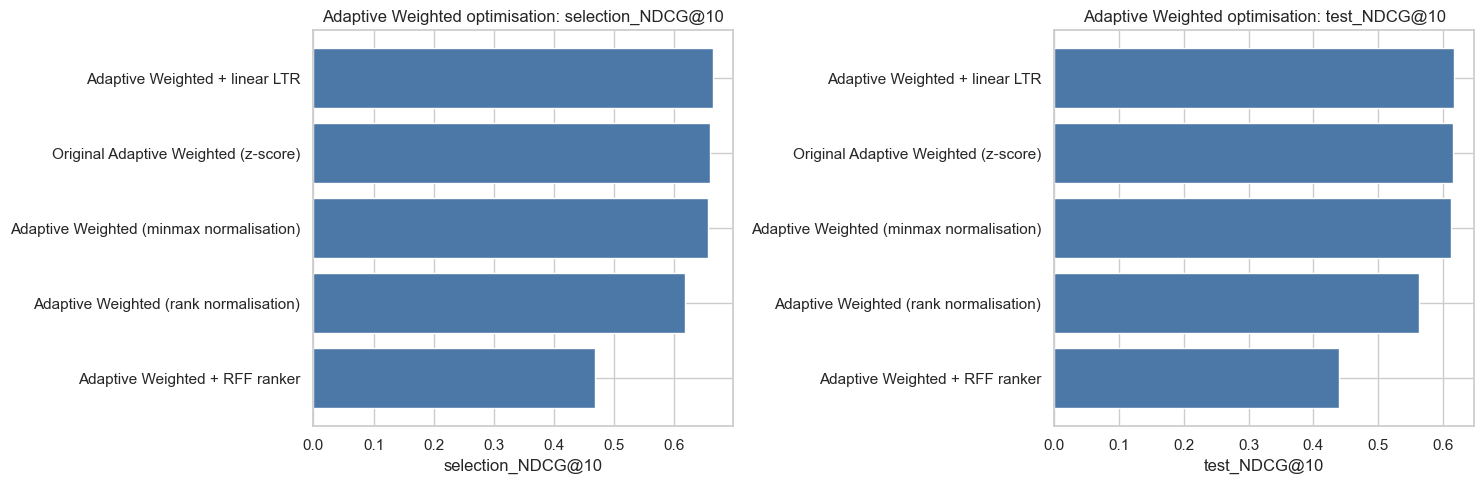

In [56]:
# --- 11.4 Optimisation routes B and C: linear Learning-to-Rank and nonlinear RFF ---
def fit_linear_ltr(users, candidates, content, cf, gru, histories, mask, seed):
    x_train, y_train = sampled_ltr_training_data(
        users, candidates, content, cf, gru, histories, mask, seed
    )
    model = make_pipeline(
        StandardScaler(),
        LogisticRegression(
            class_weight="balanced",
            max_iter=300,
            solver="lbfgs",
            random_state=seed,
        ),
    )
    model.fit(x_train, y_train)
    return model

def fit_rff_ranker(users, candidates, content, cf, gru, histories, mask, seed):
    x_train, y_train = sampled_ltr_training_data(
        users, candidates, content, cf, gru, histories, mask, seed
    )
    model = make_pipeline(
        StandardScaler(),
        RBFSampler(gamma=0.6, n_components=RFF_COMPONENTS, random_state=seed),
        LogisticRegression(
            class_weight="balanced",
            max_iter=300,
            solver="lbfgs",
            random_state=seed,
        ),
    )
    model.fit(x_train, y_train)
    return model

for label, trainer, route in [
    ("Adaptive Weighted + linear LTR", fit_linear_ltr, "Learning to Rank"),
    ("Adaptive Weighted + RFF ranker", fit_rff_ranker, "RFF"),
]:
    # Fit only on meta-training users; selection users evaluate the candidate approach.
    selection_model = trainer(
        val_users, val_candidates, val_content_scores, val_cf_scores, val_gru_scores,
        train_sequences, meta_train_mask, OPTIMISATION_SEED,
    )
    selection_scores = score_meta_ranker(
        selection_model, val_users, val_candidates, val_content_scores, val_cf_scores,
        val_gru_scores, train_sequences,
    )
    selection_ndcg = ranking_metrics(selection_scores[selection_mask])[f"NDCG@{TOP_K}"]

    # Refit using all validation users for final test inference only.
    final_model = trainer(
        val_users, val_candidates, val_content_scores, val_cf_scores, val_gru_scores,
        train_sequences, np.ones(len(val_users), dtype=bool), OPTIMISATION_SEED,
    )
    test_scores = score_meta_ranker(
        final_model, test_users, test_candidates, test_content_scores, test_cf_scores,
        test_gru_scores, test_contexts,
    )
    optimisation_score_sets[label] = (selection_scores, test_scores)
    optimisation_rows.append({
        "method": label,
        "route": route,
        "selected_weights": "learned",
        "selection_NDCG@10": selection_ndcg,
        "test_NDCG@10": ranking_metrics(test_scores)[f"NDCG@{TOP_K}"],
        "test_Recall@10": ranking_metrics(test_scores)[f"Recall@{TOP_K}"],
        "test_MRR": ranking_metrics(test_scores)["MRR"],
    })

adaptive_optimisation_results = pd.DataFrame(optimisation_rows).sort_values(
    "selection_NDCG@10", ascending=False
).reset_index(drop=True)
best_adaptive_method = str(adaptive_optimisation_results.loc[0, "method"])
best_adaptive_validation_scores, best_adaptive_test_scores = optimisation_score_sets[
    "Original Adaptive Weighted" if best_adaptive_method.startswith("Original") else best_adaptive_method
]

display(adaptive_optimisation_results)
print("Best Adaptive Weighted variant selected on held-out validation users:", best_adaptive_method)
adaptive_optimisation_results.to_csv(
    OUTPUT_DIR / "adaptive_weighted_optimisation_comparison.csv", index=False
)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for ax, metric in zip(axes, ["selection_NDCG@10", "test_NDCG@10"]):
    ordered = adaptive_optimisation_results.sort_values(metric, ascending=False)
    ax.barh(ordered["method"], ordered[metric], color="#4C78A8")
    ax.set_title(f"Adaptive Weighted optimisation: {metric}")
    ax.set_xlabel(metric)
    ax.invert_yaxis()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "adaptive_weighted_optimisation_comparison.png", dpi=180, bbox_inches="tight")
plt.show()


## 12. Final comparison

This section compares exactly six recommendation models under the shared validation/test
protocol. It deliberately excludes the popularity baseline and any future optimised
variants, so the comparison stays focused on the three component models and the three
Hybrid strategies.

,model,split,Hit@10,Recall@10,Precision@10,NDCG@10,MRR,users,CatalogueCoverage,Novelty,IntraListDiversity
19,Adaptive Weighted + linear LTR,test,0.818644,0.818644,0.081864,0.617099,0.562329,64867,0.921755,16.036634,0.630212
13,Hybrid 1: Adaptive Weighted,test,0.817195,0.817195,0.081720,0.615942,0.561382,64867,0.916702,16.140322,0.633246
15,Adaptive Weighted (minmax normalisation),test,0.814729,0.814729,0.081473,0.612017,0.557094,64867,0.908217,16.107527,0.632465
9,Hybrid 2: Cascade,test,0.801794,0.801794,0.080179,0.608813,0.557373,64867,0.871105,16.034292,0.615482
11,Hybrid 3: Switching,test,0.773583,0.773583,0.077358,0.576465,0.525090,64867,0.914623,16.283644,0.588850
17,Adaptive Weighted (rank normalisation),test,0.780520,0.780520,0.078052,0.562885,0.504503,64867,0.957392,16.348278,0.645147
5,Collaborative Filtering: Two-Tower,test,0.748902,0.748902,0.074890,0.534441,0.478403,64867,0.985969,16.478277,0.673156
21,Adaptive Weighted + RFF ranker,test,0.731373,0.731373,0.073137,0.439979,0.362372,64867,0.950309,15.986934,0.658725
3,Content: Weighted-TFIDF,test,0.591441,0.591441,0.059144,0.428251,0.393531,64867,0.818315,16.460440,0.547997
7,Sequential: GRU4Rec,test,0.640726,0.640726,0.064073,0.423703,0.371448,64867,0.832739,15.828933,0.679505


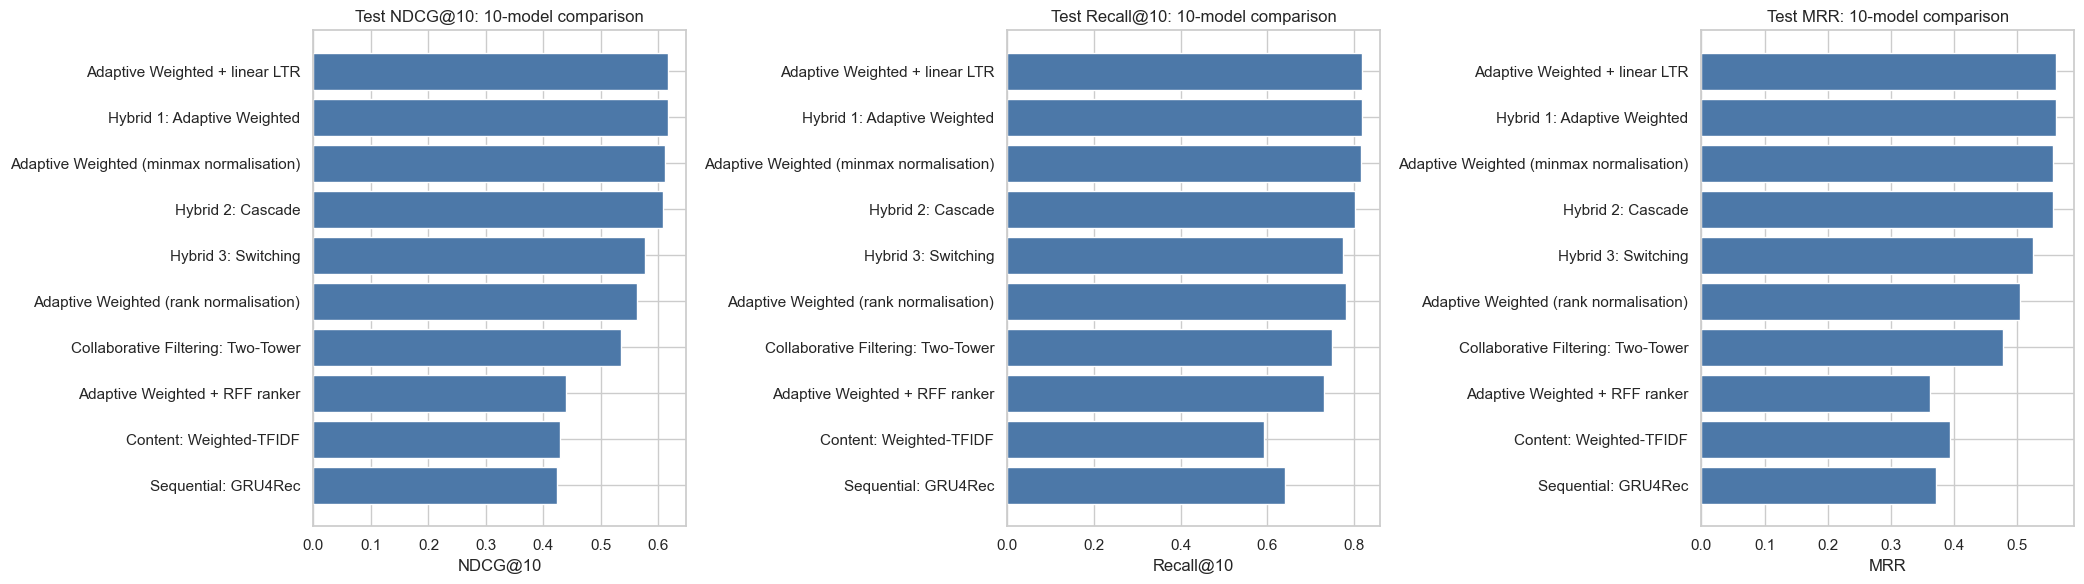

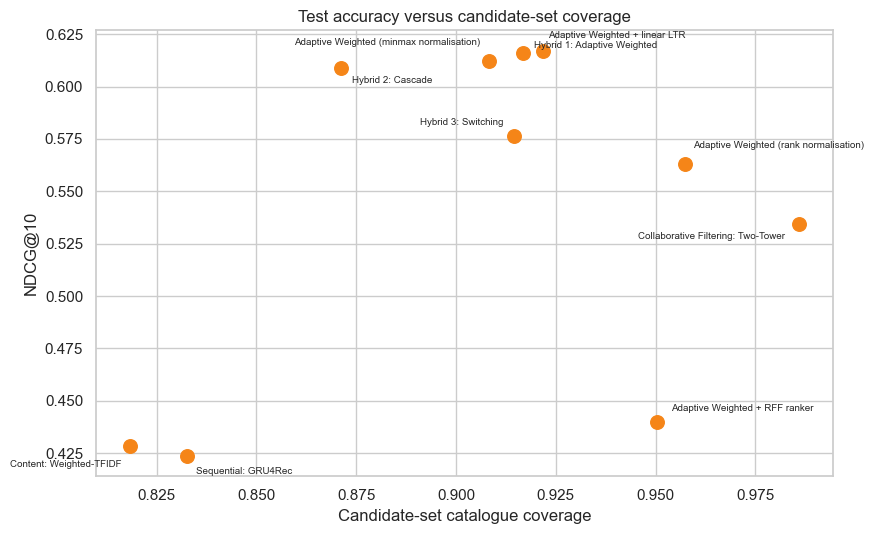

In [59]:
# Materialise the renamed Adaptive Weighted search result before comparison.
# Section 8 now produces coarse_search, fine_search and best_weights.
if "best_weights" not in globals():
    raise RuntimeError("Run Section 8 before the final comparison; best_weights is missing.")

val_adaptive_weighted_scores = weighted_fusion(
    val_content_scores, val_cf_scores, val_gru_scores, best_weights
)
test_adaptive_weighted_scores = weighted_fusion(
    test_content_scores, test_cf_scores, test_gru_scores, best_weights
)


def append_model_results(existing_results: list[dict], model_name: str, val_scores: np.ndarray, test_scores: np.ndarray) -> list[dict]:
    updated_results = [row for row in existing_results if row["model"] != model_name]
    updated_results += evaluate_model(model_name, val_scores, test_scores)
    return updated_results


results = append_model_results(
    results,
    "Hybrid 1: Adaptive Weighted",
    val_adaptive_weighted_scores,
    test_adaptive_weighted_scores,
)

if "optimisation_score_sets" not in globals():
    raise RuntimeError("Run Section 11 before the final comparison; optimisation_score_sets is missing.")

# Include the optimisation variants from Section 11 in the final comparison.
for model_name, (val_scores, test_scores) in [
    ("Adaptive Weighted (minmax normalisation)", optimisation_score_sets["Adaptive Weighted (minmax normalisation)"]),
    ("Adaptive Weighted (rank normalisation)", optimisation_score_sets["Adaptive Weighted (rank normalisation)"]),
    ("Adaptive Weighted + linear LTR", optimisation_score_sets["Adaptive Weighted + linear LTR"]),
    ("Adaptive Weighted + RFF ranker", optimisation_score_sets["Adaptive Weighted + RFF ranker"]),
]:
    results = append_model_results(results, model_name, val_scores, test_scores)

# Compare the three single models, the three original Hybrid methods and the Section 11 optimisation variants.
comparison_model_names = [
    "Content: Weighted-TFIDF",
    "Collaborative Filtering: Two-Tower",
    "Sequential: GRU4Rec",
    "Hybrid 1: Adaptive Weighted",
    "Hybrid 2: Cascade",
    "Hybrid 3: Switching",
    "Adaptive Weighted (minmax normalisation)",
    "Adaptive Weighted (rank normalisation)",
    "Adaptive Weighted + linear LTR",
    "Adaptive Weighted + RFF ranker",
]

comparison_results_df = pd.DataFrame(results)
missing_models = set(comparison_model_names) - set(comparison_results_df["model"])
if missing_models:
    raise RuntimeError(
        "Run Sections 7–10 before this comparison. Missing results for: "
        + ", ".join(sorted(missing_models))
    )

comparison_results = comparison_results_df.loc[
    comparison_results_df["model"].isin(comparison_model_names)
].copy()
comparison_results.to_csv(OUTPUT_DIR / "all_model_results_optimised.csv", index=False)

display(
    comparison_results.sort_values(
        ["split", f"NDCG@{TOP_K}"],
        ascending=[True, False],
    )
)

test_results = comparison_results.loc[
    comparison_results["split"] == "test"
].sort_values(f"NDCG@{TOP_K}", ascending=False)

fig, axes = plt.subplots(1, 3, figsize=(21, 6))
for ax, metric in zip(axes, [f"NDCG@{TOP_K}", f"Recall@{TOP_K}", "MRR"]):
    ax.barh(test_results["model"], test_results[metric], color="#4C78A8")
    ax.set_title(f"Test {metric}: {len(comparison_model_names)}-model comparison")
    ax.set_xlabel(metric)
    ax.invert_yaxis()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "all_model_results_optimised_comparison.png", dpi=180, bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.scatter(
    test_results["CatalogueCoverage"],
    test_results[f"NDCG@{TOP_K}"],
    s=95,
    color="#F58518",
)
label_offsets = [
    (4, 8), (8, 2), (-6, 10), (8, -6), (-8, 6),
    (6, 10), (-10, -6), (10, 6), (-6, -10), (6, -8),
]
for idx, (_, row) in enumerate(test_results.iterrows()):
    dx, dy = label_offsets[idx % len(label_offsets)]
    ax.annotate(
        row["model"],
        (row["CatalogueCoverage"], row[f"NDCG@{TOP_K}"]),
        fontsize=7,
        xytext=(dx, dy),
        textcoords="offset points",
        ha="left" if dx >= 0 else "right",
        va="bottom" if dy >= 0 else "top",
    )
ax.set_xlabel("Candidate-set catalogue coverage")
ax.set_ylabel(f"NDCG@{TOP_K}")
ax.set_title("Test accuracy versus candidate-set coverage")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "all_model_accuracy_coverage.png", dpi=180, bbox_inches="tight")
plt.show()